Import Library


In [149]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

Library cv2 digunakan untuk pengolahan gambar. Misalnya, mengubah warna dari RGB ke Grayscale.

Library matplotlib untuk visualisasi data, seperti menampilkan gambar ke layar dan membuat histogram

Library numpy digunakan untuk mengelola angka, seperti array dan matriks.

Inisialisasi Citra yang Akan Diolah

Selanjutnya, citra asli dibaca menggunakan cv.imread() dan disimpan ke dalam variabel citra1 dan citra2. Gambar asli ditampilkan ke layar dan dicek apakah termasuk citra RGB atau sudah grayscale. Dimensi gambar dicek menggunakan print(citra1.shape) dan print(citra2.shape).

(780, 780, 3)
(780, 780, 3)


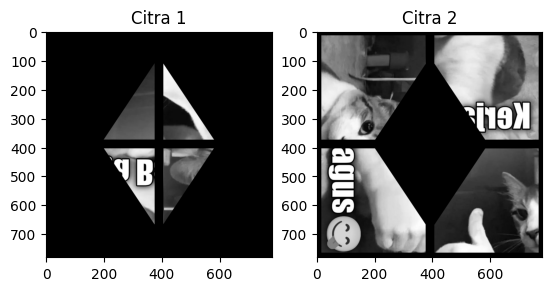

In [150]:
citra1 = cv.imread("assets/citra1.png")
citra2 = cv.imread("assets/citra2.png")

plt.subplot(1, 2, 1)
plt.title("Citra 1")
plt.imshow(citra1)
print(citra1.shape)

plt.subplot(1, 2, 2)
plt.title("Citra 2")
plt.imshow(citra2)
print(citra2.shape)

Mengubah Citra dalam Bentuk Grayscale

Oleh karena citra asli masih citra RGB maka kedua citra tersebut diubah dalam bentuk grayscale. Meskipun warnanya terlihat tidak ada perubahan, tetapi perbedaannya terlihat ketika dimensi gambarnya dilihat. Pada citra asli berbentuk 3D, setelah diubah ke grayscale menjadi 2D.

(780, 780)
(780, 780)


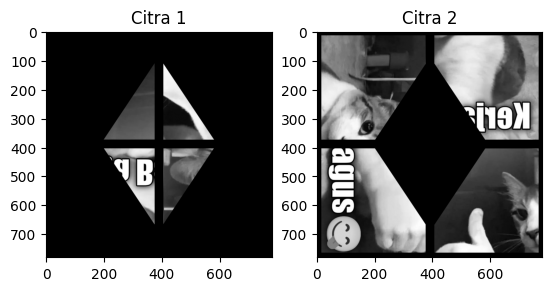

In [151]:
gray1 = cv.cvtColor(citra1, cv.COLOR_BGR2GRAY)
plt.subplot(1, 2, 1)
plt.title("Citra 1")
plt.imshow(gray1, cmap='gray')
print(gray1.shape)

gray2 = cv.cvtColor(citra2, cv.COLOR_BGR2GRAY)
plt.subplot(1, 2, 2)
plt.title("Citra 2")
plt.imshow(gray2, cmap='gray')
print(gray2.shape)

Fungsi Rotasi

In [152]:
def rotate(image, val):
    h, w = image.shape
    val = int(val) % 360
    if val == 0: return image
    elif val == 90:
        rot = np.zeros((w, h), dtype=image.dtype)
        for i in range(h):
            for j in range(w):
                rot[j, h-1-i] = image[i, j]
                
        return rot
    elif val == 180:
        rot = np.zeros_like(image, dtype=image.dtype)
        for i in range(h):
            for j in range(w):
                rot[h-1-i, w-1-j] = image[i, j]
        return rot
    elif val == 270:
        rot = np.zeros((w, h), dtype=image.dtype)
        for i in range(h):
            for j in range(w):
                rot[w-1-j, i] = image[i, j]
        return rot
    return image

Fungsi di atas merupakan fungsi untuk melakukan rotasi searah jarum jam. Fungsi tersebut menerima parameter citra dan sudut rotasi. Program akan memastikan bahwa sudut yang diterima berada dalam rentang 360 derajat. Untuk fungsi di atas, terbatas pada beberapa derajat sudut saja, yaitu 90, 180, dan 270.

Melakukan Rotasi Pada Citra

Dilakukan proses rotasi untuk citra 1 sebesar 180 derajat supaya bentuknya sesuai dengan posisi kosong yang ada pada citra 2 sehingga didapatkan hasil seperti berikut. Memutar citra sebesar 180 derajat hampir mirip dengan proses flipping.

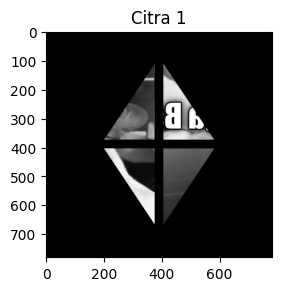

In [153]:
rotate1 = rotate(gray1, 180)
plt.subplot(1, 2, 1)
plt.title("Citra 1")
plt.imshow(rotate1, cmap='gray')

Fungsi Penjumlahan Citra

In [154]:
def penjumlahan(image1, image2):
    merge = image1 + image2
    return merge

Fungsi penjumlahan digunakan untuk menjumlahkan dua buah citra. Fungsi ini menerima dua parameter, yaitu gambar 1 dan 2. Dua buah citra bisa dijumlahkan jika dan hanya jika ukuran pikselnya sama. Kedua buah citra tersebut memiliki ukuran piksel yang sama sehingga bisa dijumlahkan.

Menjumlahkan Citra 1 dan Citra 2

Citra 1 dan 2 dijumlahkan sehingga hasilnya seperti pada gambar di bawah. Citra 2 memiliki intensitas piksel 0 berbentuk belah ketupat di tengahnya, ditambah dengan citra 1 yang memiliki instensitas piksel bukan 0 sehingga pada hasil penjumlahannya ukuran belah ketupat yang kosong tersebut diisi dengan citra 1. Begitu juga dengan citra 2 yang mengisi bagian kosong pada citra 1.

(780, 780)


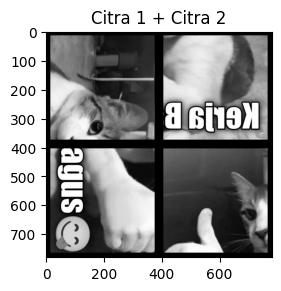

In [155]:
merged = penjumlahan(rotate1, gray2)
plt.subplot(1, 2, 1)
plt.title("Citra 1 + Citra 2")
plt.imshow(merged, cmap='gray')
print(merged.shape)

Fungsi Memotong Citra

In [156]:
def slice(image, a, b, mode='H'):
    return image[a:b, :] if mode == 'H' else image[:, a:b]

Fungsi slice digunakan untuk memotong citra menjadi beberapa bagian. Pemotongan dapat dilakukan secara horizontal maupun vertikal. Cara kerjanya dengan mengambil batas atas dan bawah.

Proses Pemotongan Citra Secara Horizontal

Citra hasil penjumlahan tadi dipotong secara horizontal sehingga menghasilkan dua buah potongan citra seperti berikut. Pemotongan pertama diambil dari 0 hingga 400 secara vertikal, dan mengambil keseluruhan piksel secara horizontal. Kemudian untuk bagian 2 dipotong dari piksel 400 sampai 780 secara vertikal dan mengambil keseluruhan bagian piksel secara horizontal.

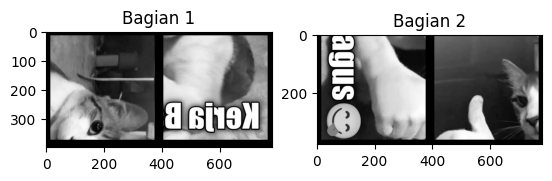

In [157]:
sliced1 = slice(merged, 0, 400, 'H')
plt.subplot(2, 2, 1)
plt.title("Bagian 1")
plt.imshow(sliced1, cmap='gray')

sliced2 = slice(merged, 400, 780, 'H')
plt.subplot(2, 2, 2)
plt.title("Bagian 2")
plt.imshow(sliced2, cmap='gray')

Proses Pemotongan Citra Secara Vertikal

Selanjutnya, citra yang dipotong secara horizontal tadi dipotong lagi secara vertikal hingga terpecah menjad empat bagian seperti gambar di bawah. Pemotongan secara vertikal juga menggunakan batas atas dan batas bawah. Bagian 1 dipotong dari 0 sampe 400 pada garis horizontalnya dan diambil semua pada bagian vertikalnya sehingga menghasilkan Bagian 1.1. Kemudian Bagian 1 juga dipotong sisanya dari 400 sampe 780 sehingga menghasilkan gambar Bagian 1.2. Hal yang sama juga berlaku untuk gambar Bagian 2 sehingga dihasilkan potongan gambar Bagian 2.1 dan Bagian 2.2.

(400, 400)
(400, 380)
(380, 400)
(380, 380)


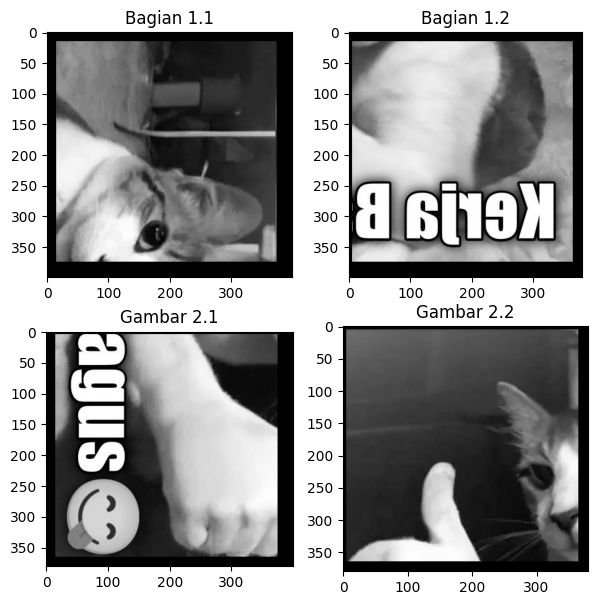

In [158]:
plt.figure(figsize=(7,7))

sliced3 = slice(sliced1, 0, 400, 'V')
plt.subplot(2, 2, 1)
plt.title("Bagian 1.1")
plt.imshow(sliced3, cmap='gray')
print(sliced3.shape)

sliced4 = slice(sliced1, 400, 780, 'V')
plt.subplot(2, 2, 2)
plt.title("Bagian 1.2")
plt.imshow(sliced4, cmap='gray')
print(sliced4.shape)

sliced5 = slice(sliced2, 0, 400, 'V')
plt.subplot(2, 2, 3)
plt.title("Gambar 2.1")
plt.imshow(sliced5, cmap='gray')
print(sliced5.shape)

sliced6 = slice(sliced2, 400, 780, 'V')
plt.subplot(2, 2, 4)
plt.title("Gambar 2.2")
plt.imshow(sliced6, cmap='gray')
print(sliced6.shape)


Fungsi Pencerminan Citra terhadap Sumbu X atau Y

In [159]:
def flip(image, mode='X'):
    h, w = image.shape
    hasil = np.zeros((h, w), dtype=image.dtype)
    for i in range(h):
        for j in range(w):
            if mode == 'X':
                hasil[i, j] = image[i, w-1-j]
            elif mode == 'Y':
                hasil[i, j] = image[h-1-i, j]
    return hasil

Fungsi flip digunakan untuk pencerminan citra. Citra yang belum sesuai posisinya akan dilakukan pencerminan supaya sesuai. Parameter yang diterima adalah gambar yang akan dicerminkan dan dicerminkan terhadap sumbu apa.

Fungsi membuat matriks kosong dengan dimensi dan tipe data yang sama dengan citra asli. Untuk flip terhadap sumbu X, posisi baris tetap, tetapi kolomnya yang dibalik. Piksel yang awalnya di kiri dipindahkan ke kanan. Untuk flip terhadap sumbu Y, posisi kolom tetap, tetapi posisi barisnya dibalik. Piksel yang awalnya di atas dipindahkan ke bawah.

Proses Pencerminan terhadap Sumbu X atau Y

Gambar 1.2 dilakukan pencerminan terhadap sumbu Y, sedangkan Gambar 2.2 dilakukan pencerminan terhadap sumbu X sehingga didapatkan hasil berikut.

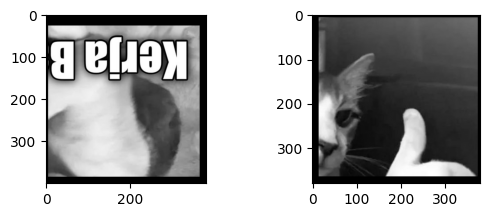

In [160]:
flip4 = flip(sliced4, 'Y')
plt.subplot(2,2,1)
plt.imshow(flip4, cmap='gray')

flip6 = flip(sliced6, 'X')
plt.subplot(2,2,2)
plt.imshow(flip6, cmap='gray')

Melakukan Rotasi Pada Beberapa Potongan Gambar Supaya Sesuai dengan Citra Asli

Selanjutnya, dilakukan rotasi pada beberapa gambar yang posisinya belum sesuai sehingga didapatkan hasilnya seperti gambar di bawah.

(400, 400)
(380, 380)
(400, 380)
(400, 380)


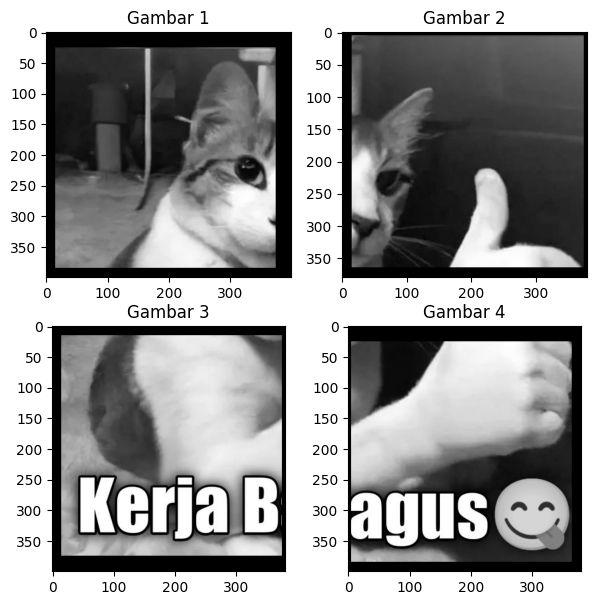

In [161]:
plt.figure(figsize=(7,7))

rotate11 = rotate(sliced3, 270)
plt.subplot(2,2,1)
plt.title("Gambar 1")
plt.imshow(rotate11, cmap='gray')
print(rotate11.shape)

plt.subplot(2,2,2)
plt.title("Gambar 2")
plt.imshow(flip6, cmap='gray')
print(flip6.shape)

rotate12 = rotate(flip4, 180)
plt.subplot(2,2,3)
plt.title("Gambar 3")
plt.imshow(rotate12, cmap='gray')
print(rotate12.shape)

rotate21 = rotate(sliced5, 270)
plt.subplot(2,2,4)
plt.title("Gambar 4")
plt.imshow(rotate21, cmap='gray')
print(rotate21.shape)

Fungsi Translasi

In [162]:
def translasi(image, shift_x=0, shift_y=0):
    image = np.array(image)
    h, w = image.shape
    hasil = np.zeros((h, w))

    for i in range(h):
        for j in range(w):
            new_i = i + shift_y
            new_j = j + shift_x
            if 0 <= new_i < h and 0 <= new_j < w:
                hasil[new_i, new_j] = image[i, j]

    return hasil

Fungsi translasi dibuat untuk menggeser posisi citra ke arah sumbu X atau Y. Fungsi ini menerima parameter gambar yang akan digeser, seberapa jauh gambar digeser secara horizontal dan vertikal.

Pada fungsi di atas, dilakukan proses penjumlahan. Penjumlahan yang dilakukan adalah menjumlahkan koordinat piksel lama dengan nilai pergeseran yang diterima oleh parameter. Terdapat pengecekan kondisi juga untuk batas piksel. Jika ada piksel yang setelah digeser berada di luar dimensi maka akan dibuang, sedangkan untuk area piksel yang hilang akibat pergeseran akan bernilai 0 makanya ada warna hitam di pinggirnya.

Proses Translasi Citra Supaya Ukuran Gambarnya Presisi

Empat potongan citra dilakukan proses translasi. Gambar 1 ditranslasi sejauh 20 piksel ke kanan dan 15 piksel ke bawah. Gambar 2 ditranslasi sejauh 15 piksel ke kiri dan 15 piksel ke bawah. Gambar 3 ditranslasi sejauh 5 piksel ke kanan dan 15 piksel ke atas. Gambar 4 ditranslasi sejauh 5 piksel ke kiri dan 25 piksel ke atas.

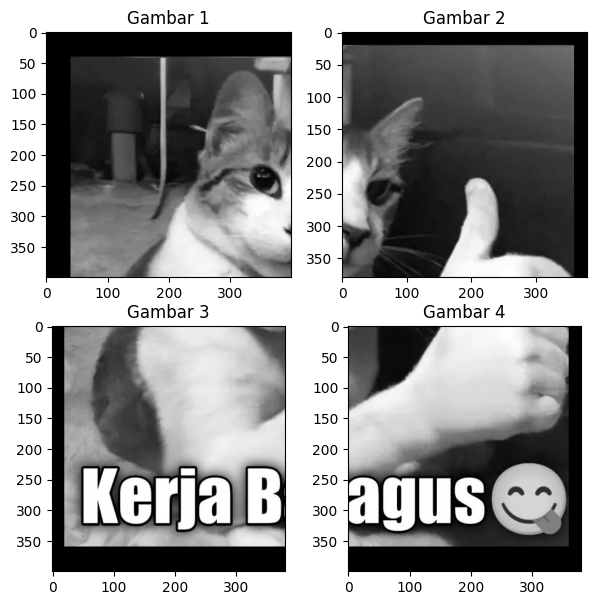

In [163]:
plt.figure(figsize=(7,7))

trans1 = translasi(rotate11, 25, 15)
trans2 = translasi(flip6, -15, 15)
trans3 = translasi(rotate12, 5, -15)
trans4 = translasi(rotate21, -5, -25)

plt.subplot(2, 2, 1)
plt.title("Gambar 1")
plt.imshow(trans1, cmap='gray')

plt.subplot(2, 2, 2)
plt.title("Gambar 2")
plt.imshow(trans2, cmap='gray')

plt.subplot(2, 2, 3)
plt.title("Gambar 3")
plt.imshow(trans3, cmap='gray')

plt.subplot(2, 2, 4)
plt.title("Gambar 4")
plt.imshow(trans4, cmap='gray')

Fungsi Dilatasi

In [164]:
def dilatasi(image, t=0, b=0, l=0, r=0): 
    h, w = image.shape 
    # skala 2x lipat 
    dilated = np.zeros((h * 2, w * 2)).astype(int) 
    for y in range(h * 2): 
        for x in range(w * 2): 
            dilated[y][x] = image[int(y / 2)][int(x / 2)] 
    # normalisasi (crop) sisi luar 
    sy, ey = max(0, t), min(h * 2, h * 2 - b) 
    sx, ex = max(0, l), min(w * 2, w * 2 - r) 
    return dilated[sy:ey, sx:ex]

Fungsi dilatasi digunakan untuk melakukan perbesaran citra dengan skala perbesaran 2, kemudian memotong hasilnya berdasarkan parameter yang diinputkan. 

Fungsi membuat matriks baru dengan ukuran 2x lipat dari lebar dan tinggi asilnya. Setiap piksel asli diperluas menjadi 4 piksel baru. Setelah dilakukan penskalaan, dilakukan pemotongan berdasarkan nilai t, b, l, dan r yang diinputkan.

Proses Dilatasi

Selanjutnya, setiap potongan gambar dilakukan memotongan pada beberapa bagian untuk menghilangkan bagian-bagian yang berwarna hitam.

Gambar 1 didilatasi sebesar 100 piksel bagian atas dan 100 piksel bagian kiri.
Gambar 2 didilatasi sebesar 60 piksel bagian atas dan 60 piksel bagian kanan.
Gambar 3 didilatasi sebesar 100 piksel bagian bawah dan 60 piksel bagian kiri.
Gambar 4 didilatasi sebesar 100 piksel bagian bawah dan 60 piksel bagian kanan.

(700, 700)
(700, 700)
(700, 700)
(700, 700)


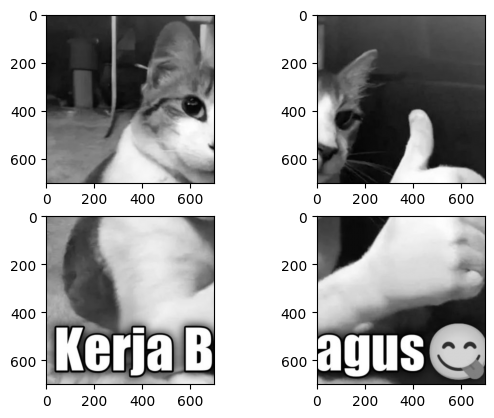

In [165]:
dilated1 = dilatasi(trans1, 100,0,100,0)
plt.subplot(2,2,1)
plt.imshow(dilated1, cmap='gray')
print(dilated1.shape)

dilated2 = dilatasi(trans2, 60,0,0,60)
plt.subplot(2,2,2)
plt.imshow(dilated2, cmap='gray')
print(dilated2.shape)

dilated3 = dilatasi(trans3, 0,100,60,0)
plt.subplot(2,2,3)
plt.imshow(dilated3, cmap='gray')
print(dilated3.shape)

dilated4 = dilatasi(trans4, 0,100,0,60)
plt.subplot(2,2,4)
plt.imshow(dilated4, cmap='gray')
print(dilated4.shape)

Fungsi Merge secara Horizontal atau Vertikal

In [166]:
def mergeH(citra_1, citra_2): 
    c1, c2 = np.array(citra_1), np.array(citra_2) 
    tinggi = max(c1.shape[0], c2.shape[0]) 
    lebar = c1.shape[1] + c2.shape[1] 
    hasil = np.zeros((tinggi, lebar)).astype(int) 
    hasil[0:c1.shape[0], 0:c1.shape[1]] = c1 
    hasil[0:c2.shape[0], c1.shape[1]:] = c2 
    return hasil 

def mergeV(citra_1, citra_2): 
    c1, c2 = np.array(citra_1), np.array(citra_2) 
    tinggi = c1.shape[0] + c2.shape[0] 
    lebar = max(c1.shape[1], c2.shape[1]) 
    hasil = np.zeros((tinggi, lebar)).astype(int) 
    hasil[0:c1.shape[0], 0:c1.shape[1]] = c1 
    hasil[c1.shape[0]:, 0:c2.shape[1]] = c2 
    return hasil

Fungsi di atas digunakan untuk menggabungkan dua citra menjadi satu. Terdapat penggabungan secara horizontal maupun vertikal.

mergeH:
Fungsi tersebut menyusun citra dari kiri ke kanan. Awalnya citra 1 dan citra 2 diubah dalam bentuk matriks yang disimpan ke c1 sama c2. Kemudian membuat tinggi matriks sesuai dengan citra yang paling tinggi, lebarnya jumlah total lebar dua buah citra yang akan digabungkan. Misal ada citra yang ukurannya lebih kecil dari matriks kosong yang disediakan, areanya otomatis warna hitam alias 0.

mergeV:
Fungsi ini menyusun citra dari atas ke bawah. Awalnya citra 1 dan citra 2 diubah dalam bentuk matriks yang disimpan ke c1 sama c2. Lebar matriksnya diambil dari citra yang paling lebar, tingginya jumlah total kedua citra. Misal ada citra yang ukurannya lebih kecil dari matriks kosong yang disediakan, areanya otomatis warna hitam alias 0.

Merge Citra Secara Horizontal

Empat potongan gambar dilakukan penggabungan secara horizontal sehingga didapatkan hasil seperti gambar di bawah.

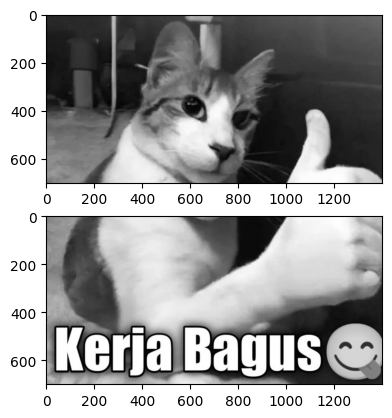

In [167]:
merge12 = mergeH(dilated1, dilated2)
plt.subplot(2, 1, 1)
plt.imshow(merge12, cmap='gray')

merge34 = mergeH(dilated3, dilated4)
plt.subplot(2, 1, 2)
plt.imshow(merge34, cmap='gray')

Merge Citra Secara Vertikal

Gambar yang telah digabung secara horizontal sebelumnya, digabungkan lagi secara vertikal sehingga diperoleh hasil seperti gambar di bawah. Gambar yang posisi awalnya tidak sesuai, setelah dilakukan beberapa operasi citra, terbentuk sebuah gambar utuh.

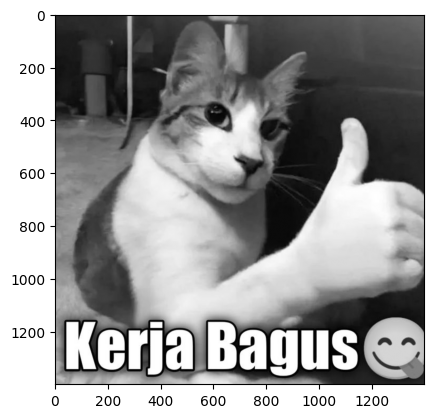

In [168]:
merge1234 = mergeV(merge12, merge34)
plt.imshow(merge1234, cmap='gray')

Pembagian dengan Skalar dan Normalisasi Min-Max
Rumus: (x - min) / (max - min) * 255

Kode img_divided = (merge1234/2).astype(np.float32) membagi semua nilai piksel dengan 2. Hasilnya, citra yang awalnya berada di rentang 0-255 mengalami penyempitan sehingga berada di rentang 0-127. Kemudian mengubah tipe data ke float supaya perhitungan matematisnya presisi.

selanjutnya dicari nilai minimum dan maksimum dari piksel untuk normalisasi (min-max scaling)

Kode img_normalized = ((img_divided - img_min) / (img_max - img_min)) * 255. Citra yang awalnya dipersempit dari rentang 0-127 dilakukan normalisasi untuk memperbesar rentangnya menjadi 0-255 lagi.

Terakhir, tipe datanya diubah kembali ke integer 8-bit.

In [169]:
img_divided = (merge1234/2).astype(np.float32)

img_min = np.min(img_divided)
img_max = np.max(img_divided)


img_normalized = ((img_divided - img_min) / (img_max - img_min)) * 255


img_divided_uint8 = img_divided.astype(np.uint8)
img_normalized = img_normalized.astype(np.uint8)


Hasil pembagian dengan skalar 2 terlihat pada gambar di bawah ini. Jujur ga tau letak bedanya di mana ini sama hasil merge di atas.

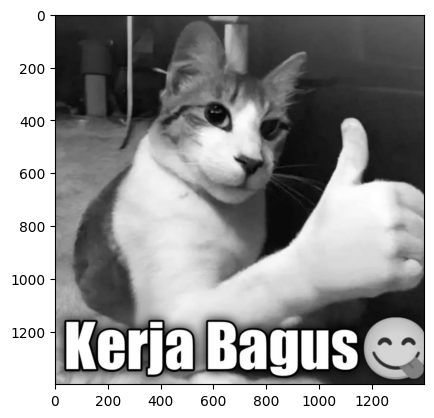

In [170]:
plt.imshow(img_divided_uint8, cmap='gray')


Fungsi Menampilkan Histogram

Fungsi ini digunakan untuk melihat distribusi intensitas warna dari sebuah citra. Jika nilai maksimal pikselnya lebih dari 1.0 maka akan ditampilkan histogram dengan rentang 0-255, sedangkan jika tidak lebih dari 1.0 maka akan ditampilkan histogram dengan rentang 0.0-1.0.

Fungsi ravel() digunakan untuk mengubah matriks menjadi 1D supaya bisa dihitung frekuensi pikselnya. Parameter bins digunakan karena citra digital memiliki 256 tingkatan warna. Setiap bin mewakili satu tingkat kecerahan tertentu.

Sumbu X menunjukkan tingkat kecerahan. Sumbu Y menunjukkan jumlah piksel yang memiliki tingkat kecerahan tertentu.

In [171]:
def tampilkan_histogram(img):
    max_val = np.max(img)
    x_range = [0, 255] if max_val > 1.0 else [0, 1.0]
    
    plt.figure(figsize=(8, 4))
    # ravel() mengubah matriks 2D menjadi 1D
    plt.hist(img.ravel(), bins=256, range=x_range, alpha=0.7)
    
    plt.xlabel("Intensitas Piksel")
    plt.ylabel("Frekuensi")
    plt.grid(axis='y', alpha=0.3)
    plt.show()

Histogram Setelah Pembagian Skalar

Gambar di bawah ini merupakan histogram dari citra yang dibagi dengan skalar 2. Efeknya adalah nilai piksel yang tadinya sampe 255, menyusut menjadi sekitar 127 maksimalnya

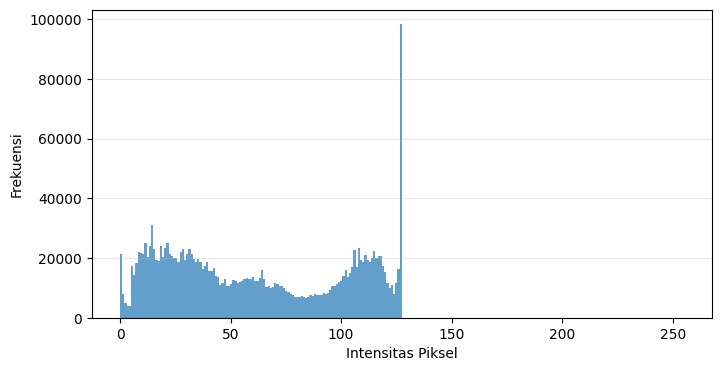

In [172]:
histWithScalar = tampilkan_histogram(img_divided_uint8)

Histogram Normalisasi Min-Max (Contrast Stretching)

selanjutnya citra yang dibagi 2 tadi dilakukan normalisasi dengan tujuan untuk memetakan kembali nilai yang dari rentang 0-127 ke 0-255 sehingga didapatkan histogram seperti berikut ini.

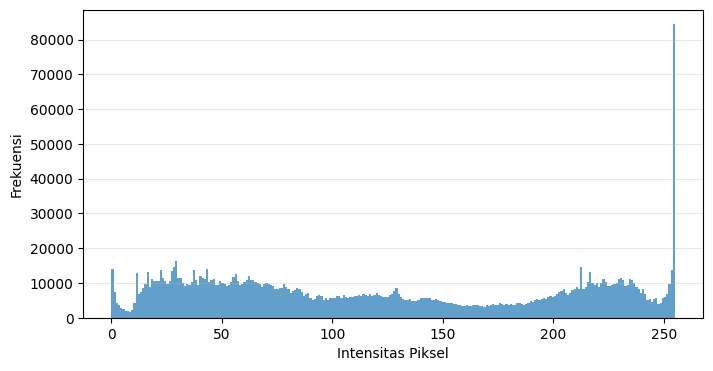

In [173]:
histScalarNormalized = tampilkan_histogram(img_normalized)

Biar lihat wujud gambarnya setelah pemetaan pake skala 0-255 lagi buat perbandingan sama rentang 0-127. Jujur ga ada bedanya saya rasa ini.

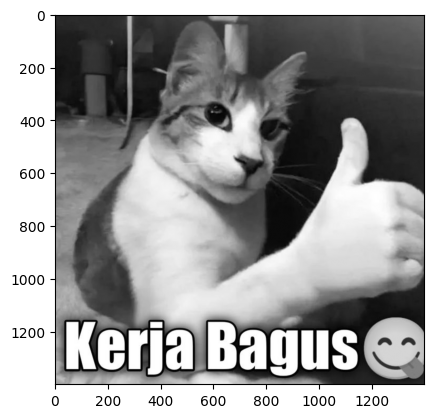

In [174]:
plt.imshow(img_normalized, cmap='gray')

Fungsi Penambahan Zero Padding

In [175]:
def zero_padding(img, pad_size=2):
    h, w = img.shape
    # Buat kanvas kosong (hitam) dengan ukuran lebih besar
    padded_img = np.zeros((h + 2 * pad_size, w + 2 * pad_size))
    # Masukkan gambar asli ke tengah kanvas
    padded_img[pad_size : pad_size + h, pad_size : pad_size + w] = img
    return padded_img

Fungsi di atas digunakan untuk menambahkan angka nol pada sisi terluar matriks gambar. Fungsi tersebut membuat matriks kosong dengan dimensi yang lebih besar dari citra asli. Citra asli tidak diletakkan di koordinat (0,0), melainkan digeser sejauh nilai pad_size.

Fungsi Konvolusi

In [176]:
def konvolusi(img, kernel):
    img_padded = zero_padding(img, pad_size=2)
    
    h_pad, w_pad = img_padded.shape
    h_k, w_k = kernel.shape
    
    
    output = np.zeros(img.shape)
    
    # 3. Proses Konvolusi
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            # Ambil area sebesar ukuran kernel
            region = img_padded[y : y + h_k, x : x + w_k]
            # Perkalian elemen-per-elemen dan dijumlahkan
            output[y, x] = np.sum(region * kernel)
            
    return output


kernel_custom = np.array([
    [-0.1, -0.1, -0.1, -0.1],
    [-0.1,  0.4,  0.4, -0.1],
    [-0.1,  0.4,  0.4, -0.1],
    [-0.1, -0.1, -0.1, -0.1]
])

hasil_konvolusi = konvolusi(img_normalized, kernel_custom)

Fungsi konvolusi digunakan untuk memproses citra dengan menggunakan sebuah matriks keecil yang disebut kernel. Fungsi memanggil zero_padding supaya kernel bisa berpusat pada piksel paling pinggir citra asli. Kemudian fungsi mengambil area matriks dari gambar yang ukurannya sama dengan ukuran kernel. Setiap piksel di area tersebut dikalikan dengan nilai kernel yang bersesuaian. Hasil perkalian tersebut dijumlahkan menjadi satu nilai, di mana nilai tersbeut menjadi nilai piksel baru di koordinat tersebut.

Fungsi Clipping

In [177]:
def apply_clipping(img):
    
    row, col = img.shape
    result = img.astype(np.float32)
    
    for i in range(row):
        for j in range(col):
            if result[i, j] > 255:
                result[i, j] = 255
            elif result[i, j] < 0:
                result[i, j] = 0
            else:
                result[i, j] = result[i,j]
    
    return result.astype(np.uint8)

Fungsi clipping digunakan untuk memastikan bahwa setiap nilai pixel berada dalam rentang yang valid untuk ditampilkan. Jika nilai piksel pada suatu koordinat lebih dari 255 maka akan diubah menjadi 255. Jika nilai piksel pada suatu kordinat kurang dari 0 maka akan diubah menjadi 0. Untuk koordinat yang nilai pikselnya berada di rentang 0-255 tidak diubah sama sekali.

Proses Menambahkan Zero Padding Pada Citra

Pertama-tama, dilakukan penambahan zero padding pada gambar sehingga diperoleh hasil seperti gambar di bawah.

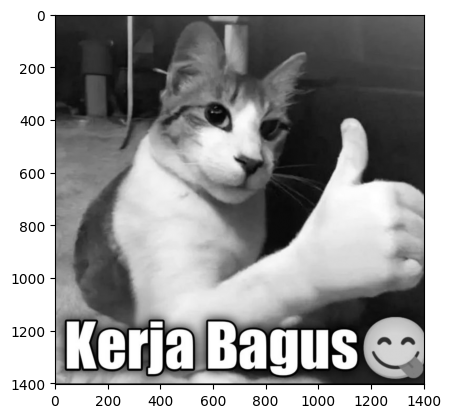

In [178]:
zeroPad = zero_padding(img_normalized)
plt.imshow(zeroPad, cmap='gray')

Proses Konvolusi setelah Penambahan Zero Padding

Selanjutnya dilakukan proses konvolusi pada citra menggunakan kernel yang diinisialisasi sebelumnya sehingga didapatkan hasil seperti gambar di bawah. Terlihat bahwa gambarnya memiliki kontras yang rendah.

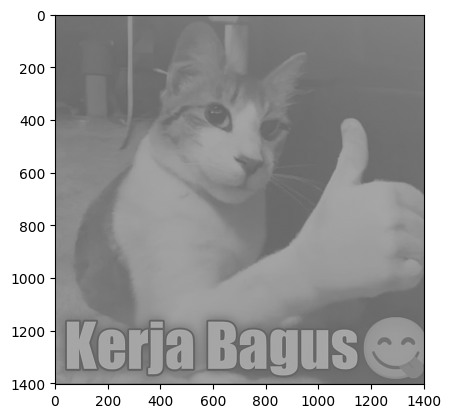

In [179]:
normalisasiKonvolusi = konvolusi(zeroPad, kernel_custom)
plt.imshow(normalisasiKonvolusi, cmap='gray')

Proses Clipping

Selanjutnya, dilakukan proses clipping. Setelah dilakukan proses clipping kontras gambar terlihat lebih bagus, tetapi gambar terlihat gelap.

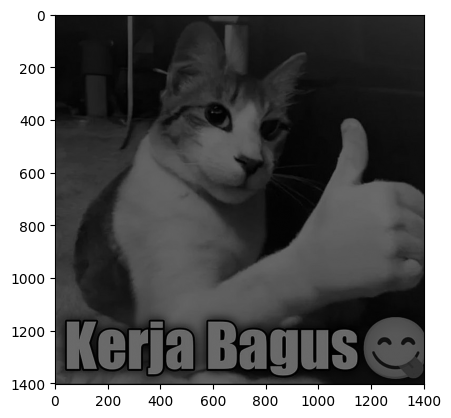

In [180]:
clipKonvolusi = apply_clipping(normalisasiKonvolusi)
plt.imshow(clipKonvolusi, cmap='gray')

Histogram setelah Clipping

Berdasarkan gambar hasil clipping, dilihat distribusi frekuensinya melalui grafik histogram. Grafik menunjukkan bahwa intensitas citra menumpuk pada sisi kiri dengan distribusi yang merata. Hal ini menunjukkan bahwa gambar tersebut merupakan gambar yang gelap.

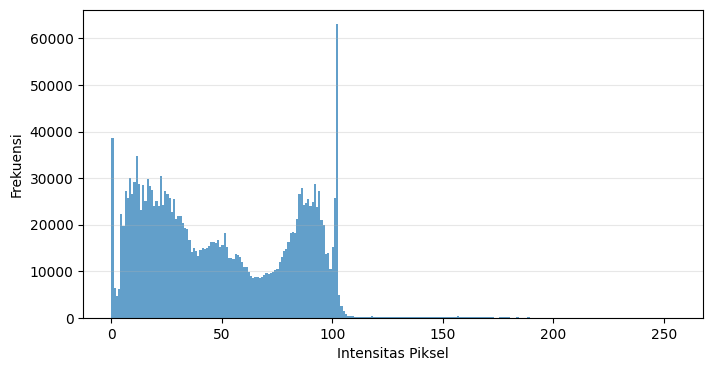

In [181]:
clipHistogram = tampilkan_histogram(clipKonvolusi)

Analisis Hasil Akhir

Pada jurnal ini memproses dua buah citra melalui beberapa rangkaian proses. Kedua citra dibaca menggunakan cv dan dilihat apakah termasuk citra grayscale atau bukan. Hasil pembacaan citra menunjukkan bahwa kedua citra bukan grayscale sehingga perlu diubah ke grayscale. Setelah diubah ke grayscale, dilakukan proses rotasi sebesar 180 derajat pada Citra 1. Setelah dilakukan rotasi, citra 1 dan 2 dijumlahkan sehingga membentuk satu gambar. Namun, gambar yang sudah disatukan tersebut posisinya masih tidak sesuai dengan yang diinginkan sehingga perlu dilakukan beberapa operasi citra.

Citra yang dijumlahkan tersebut dipotong menjadi empat bagian sehingga didapatkan Gambar 1.1, Gambar 1.2, Gambar 2.1, dan Gambar 2.2. Gambar 1.2 dilakukan pencerminan terhadap sumbu Y, sedangkan Gambar 2.2 dilakukan pencerminan terhadap sumbu X.

Oleh karena posisi gambarnya masih belum sesuai, dilakukan perotasian. Gambar 1.1 dirotasi sebesar 270 derajat, Gambar 1.2 dirotasi sebesar 180 derajat, dan Gambar 2.1 dirotasi sebesar 270 derajat. Proses rotasi dilakukan searah jarum jam.

Setelah rotasi, posisi gambar sudah sesuai dengan yang diinginkan. 

Selanjutnya dilakukan proses translasi dengan rincian penjelasan sebagai berikut.

Gambar 1 ditranslasi sejauh 20 piksel ke kanan dan 15 piksel ke bawah. Gambar 2 ditranslasi sejauh 15 piksel ke kiri dan 15 piksel ke bawah. Gambar 3 ditranslasi sejauh 5 piksel ke kanan dan 15 piksel ke atas. Gambar 4 ditranslasi sejauh 5 piksel ke kiri dan 25 piksel ke atas.

Setelah proses translasi, masih menyisakan pinggiran hitam sehingga perlu dipotong untuk mendapatkan hasil sesuai yang diinginkan. Rincian proses dilatasi sebagai berikut.

Gambar 1 didilatasi sebesar 100 piksel bagian atas dan 100 piksel bagian kiri.
Gambar 2 didilatasi sebesar 60 piksel bagian atas dan 60 piksel bagian kanan.
Gambar 3 didilatasi sebesar 100 piksel bagian bawah dan 60 piksel bagian kiri.
Gambar 4 didilatasi sebesar 100 piksel bagian bawah dan 60 piksel bagian kanan.

Keempat potongan gambar tersebut digabungkan sehingga diperoleh satu gambar utuh. Gambar utuh tersebut kemudian dilakukan proses pembagian dengan skalar 2 sehingga intensitas warnanya menyempit, dari 0-255 menjadi 0-127. Setelah dilakukan pembagian, citra tersebut dilakukan normalisasi min-max sehingga rentangnya kembali menjadi 0-255 sehingga kontrasnya meningkat.

Selanjutnya dilakukan proses konvolusi. Namun, sebelum proses konvolusi terdapat penambahan zero padding supaya saat memproses citra tidak ada bagian yang hilang. Konvolusi dilakukan dengan ukuran kernel 4x4. Hasil konvolusi menunjukkan citra dengan kontras yang rendah.

Hasil konvolusi dilakukan proses clipping supaya tetap berada di rentang 0-255. Untuk hasil konvolusi yang nilai pikselnya lebih dari 255 akan menjadi 255, nilai piksel yang kurang dari 0 menjadi 0, dan yang berada di rentang 0-255 akan tetap nilai pikselnya.

Setelah proses clipping, kontras gambar terlihat lebih baik. Namun, gambar yang dihasilkan merupakan gambar kontras tinggi yang gelap.